## Import Libraries

In [ ]:

from google.colab import files
print("Upload kaggle.json (Kaggle → Account → Create New API Token):")
uploaded = files.upload()

!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d parohod/warp-waste-recycling-plant-dataset
!unzip -q warp-waste-recycling-plant-dataset.zip -d /content/WaRP

DETECTION_PATH = '/content/WaRP/Warp-D'
!ls {DETECTION_PATH}

Upload kaggle.json (Kaggle → Account → Create New API Token):


Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/parohod/warp-waste-recycling-plant-dataset
License(s): CC0-1.0
warp-waste-recycling-plant-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
replace /content/WaRP/.idea/.gitignore? [y]es, [n]o, [A]ll, [N]one, [r]ename: classes.txt  test  train


In [ ]:

# Inspect dataset folder structure
# and count images in common split folders

import os
from pathlib import Path

# Root directory of dataset
SRC = Path('/content/WaRP/Warp-D')


# Print all top-level files/folders inside dataset
print("Top-level contents of WaRP-D source:")

for item in sorted(SRC.iterdir()):

    # Add "/" after folders for clarity
    if item.is_dir():
        print(f"  {item.name}/")
    else:
        print(f"  {item.name}")


# Check common split names
print("\nImage counts per split (if present):")

for split in [
    'train', 'val', 'valid', 'test',
    'Train', 'Val', 'Test'
]:

    # Expected image folder path
    p = SRC / split / 'images'

    # If folder exists, count images
    if p.exists():

        # Count all files in folder
        n = len(list(p.glob('*')))

        print(f"  {split}/images : {n} images")

Top-level contents of WaRP-D source:
  classes.txt
  test/
  train/

Image counts per split (if present):
  train/images : 2452 images
  test/images : 522 images


In [ ]:

# Auto-detect dataset splits and remap
# 28 original classes -> 5 super classes

import os
import shutil
import random
from pathlib import Path


# Original 28 leaf classes
leaf_classes = [
    'bottle-blue', 'bottle-green', 'bottle-dark', 'bottle-milk',
    'bottle-transp', 'bottle-multicolor', 'bottle-yogurt', 'bottle-oil',
    'bottle-blue5l', 'bottle-blue5l-full', 'bottle-blue-full',
    'bottle-dark-full', 'bottle-green-full', 'bottle-milk-full',
    'bottle-multicolorv-full', 'bottle-transp-full',
    'bottle-yogurt-full', 'bottle-oil-full',
    'detergent-color', 'detergent-transparent',
    'detergent-box', 'canister', 'cans',
    'juice-cardboard', 'milk-cardboard',
    'unknown-plastic', 'glass-transp', 'glass-dark'
]


# New reduced classes (5 classes)
super_classes = [
    'bottle',
    'canister',
    'cans',
    'cardboard',
    'detergent'
]


# Map old class IDs -> new class IDs
leaf_to_super = {}

for i, name in enumerate(leaf_classes):

    # Bottle-like classes grouped together
    if (
        name.startswith('bottle')
        or name.startswith('glass')
        or name == 'unknown-plastic'
    ):
        leaf_to_super[i] = 0

    elif name == 'canister':
        leaf_to_super[i] = 1

    elif name == 'cans':
        leaf_to_super[i] = 2

    elif name.endswith('cardboard'):
        leaf_to_super[i] = 3

    elif name.startswith('detergent'):
        leaf_to_super[i] = 4


# Source and destination folders
SRC = Path('/content/WaRP/Warp-D')
DST = Path('/content/WaRP-D-Super')

# Remove old destination folder if exists
if DST.exists():
    shutil.rmtree(DST)


# Auto-detect dataset split names
def find_split(src_root, candidates):

    for c in candidates:

        split_path = src_root / c / 'images'

        # Exists and contains files
        if split_path.exists() and any(split_path.iterdir()):
            return c

    return None


# Detect train / validation / test folders
train_name = find_split(SRC, ['train', 'Train', 'training'])
val_name   = find_split(SRC, ['valid', 'val', 'Val', 'Valid', 'validation'])
test_name  = find_split(SRC, ['test', 'Test', 'testing'])

print(
    f"Detected source splits -> "
    f"train: {train_name} | "
    f"val: {val_name} | "
    f"test: {test_name}"
)


# Convert label files to new 5-class format
def remap_labels_dir(src_lbl_dir, dst_lbl_dir):

    dst_lbl_dir.mkdir(parents=True, exist_ok=True)

    for lbl in src_lbl_dir.glob('*.txt'):

        out = []

        for line in lbl.read_text().strip().splitlines():

            parts = line.split()

            # Skip invalid lines
            if len(parts) < 5:
                continue

            old_class = int(parts[0])

            # New class ID
            sup = leaf_to_super.get(old_class)

            if sup is None:
                continue

            # Replace class id, keep bbox coords
            out.append(f"{sup} {' '.join(parts[1:])}")

        # Save remapped label file
        (dst_lbl_dir / lbl.name).write_text('\n'.join(out))


# Copy one dataset split
def copy_split(src_split, dst_split):

    # Create folders
    (DST / dst_split / 'images').mkdir(parents=True, exist_ok=True)
    (DST / dst_split / 'labels').mkdir(parents=True, exist_ok=True)

    # Copy images
    for img in (SRC / src_split / 'images').glob('*'):
        shutil.copy(
            img,
            DST / dst_split / 'images' / img.name
        )

    # Convert labels
    remap_labels_dir(
        SRC / src_split / 'labels',
        DST / dst_split / 'labels'
    )


# Must have train + test splits
assert train_name and test_name, \
    "Source must have at least train and test splits"


# Copy train and test
copy_split(train_name, 'train')
copy_split(test_name, 'test')


# If no validation split exists:
# create 15% validation from train
if val_name is None:

    print("No validation split found in source — carving 15% out of train.")

    random.seed(42)   # reproducible split

    train_imgs = sorted(
        (DST / 'train' / 'images').glob('*')
    )

    n_val = max(1, int(0.15 * len(train_imgs)))

    val_imgs = random.sample(train_imgs, n_val)

    # Create validation folders
    (DST / 'valid' / 'images').mkdir(parents=True, exist_ok=True)
    (DST / 'valid' / 'labels').mkdir(parents=True, exist_ok=True)

    for img in val_imgs:

        lbl = (
            DST / 'train' / 'labels' /
            (img.stem + '.txt')
        )

        # Move image
        shutil.move(
            img,
            DST / 'valid' / 'images' / img.name
        )

        # Move label if exists
        if lbl.exists():
            shutil.move(
                lbl,
                DST / 'valid' / 'labels' / lbl.name
            )

# If validation split exists, copy directly
else:
    copy_split(val_name, 'valid')


# Final sanity check
for s in ['train', 'valid', 'test']:

    n_img = len(list((DST / s / 'images').glob('*')))
    n_lbl = len(list((DST / s / 'labels').glob('*')))

    print(
        f"  {s:>5}: "
        f"{n_img:>5} images | "
        f"{n_lbl:>5} label files"
    )


# Final dataset path
print(f"\nReady at: {DST}")

Detected source splits -> train: train | val: None | test: test
No validation split found in source — carving 15% out of train.
  train:  2085 images |  2085 label files
  valid:   367 images |   367 label files
   test:   522 images |   522 label files

Ready at: /content/WaRP-D-Super


In [ ]:
#Build the 5-class data.yaml
import yaml

data_yaml = {
    'path' : str(DST),
    'train': 'train/images',
    'val'  : 'valid/images',
    'test' : 'test/images',
    'nc'   : 5,
    'names': super_classes
}
with open('/content/warp_super.yaml', 'w') as f:
    yaml.dump(data_yaml, f, sort_keys=False)

!cat /content/warp_super.yaml

path: /content/WaRP-D-Super
train: train/images
val: valid/images
test: test/images
nc: 5
names:
- bottle
- canister
- cans
- cardboard
- detergent


In [ ]:
!pip uninstall -y ultralytics
!pip install --no-cache-dir "ultralytics>=8.3.78"

import ultralytics
print(f"Ultralytics version: {ultralytics.__version__}")
# Must show 8.3.78 or higher

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 312.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics version: 8.4.48


In [ ]:
# CELL: Mount Google Drive
from google.colab import drive
import os

drive.mount('/content/drive')
DRIVE_DIR = '/content/drive/MyDrive/WaRP_Detection'
os.makedirs(DRIVE_DIR, exist_ok=True)
print(f"Drive folder ready: {DRIVE_DIR}")

Mounted at /content/drive
Drive folder ready: /content/drive/MyDrive/WaRP_Detection


In [ ]:
# CELL 5: YOLOv11-m on 5 super-classes (with Drive backup)
from ultralytics import YOLO
import time, shutil

model_yolo = YOLO('yolo11m.pt')   # pretrained starter is already at /content/

t0 = time.time()
results_yolo = model_yolo.train(
    data='/content/warp_super.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    name='yolo11m_warp_super',
    optimizer='AdamW',
    lr0=0.001,
    weight_decay=0.0005,
    patience=15,
    device=0,
    amp=True,
    cos_lr=True,
    close_mosaic=5,
    mixup=0.1,
    warmup_epochs=2,
    seed=42,
    plots=True,
    exist_ok=True
)
yolo_time = time.time() - t0
print(f"\nYOLOv11-m training time: {yolo_time/60:.2f} min")

# Validate on test split
metrics_yolo = model_yolo.val(
    data='/content/warp_super.yaml',
    split='test',
    plots=True
)
print("\n===== YOLOv11-m  (5-class super-detector) =====")
print(f"mAP@0.5      : {metrics_yolo.box.map50:.4f}")
print(f"mAP@0.5:0.95 : {metrics_yolo.box.map:.4f}")
print(f"Precision    : {metrics_yolo.box.mp:.4f}")
print(f"Recall       : {metrics_yolo.box.mr:.4f}")

# DRIVE BACKUP
RUN_DIR = '/content/runs/detect/yolo11m_warp_super'
shutil.copytree(RUN_DIR, f'{DRIVE_DIR}/yolo11m_warp_super', dirs_exist_ok=True)
print(f"\n✓ Full run folder mirrored to Drive: {DRIVE_DIR}/yolo11m_warp_super")
print("  weights, plots, confusion matrix, PR curves — all backed up")

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=5, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/warp_super.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11m_warp_super, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=

In [ ]:

# Search for saved model weight files (.pt)
# and verify dataset folders still exist


import os
import glob


# Print section header
print("=" * 60)
print("Searching for any .pt weight files on this Colab VM...")
print("=" * 60)


# Common folders where weights may exist
search_roots = [
    '/content',
    '/content/runs',
    '/root',
    '/tmp'
]


# Store discovered weight files
found = []


# Search recursively for .pt file
for root in search_roots:

    if os.path.exists(root):

        for path in glob.glob(
            f'{root}/**/*.pt',
            recursive=True
        ):

            # File size in MB
            size_mb = os.path.getsize(path) / 1e6

            found.append((path, size_mb))


# Print results
if not found:

    print("\n No .pt files found anywhere.")
    print("   Training output was wiped.")
    print("   Re-train model OR mount Drive backup.")

else:

    print(f"\n Found {len(found)} weight file(s):")

    # Show largest files first
    for p, s in sorted(
        found,
        key=lambda x: -x[1]
    ):
        print(f"   {s:>6.1f} MB  {p}")


# Check if dataset folders still exist
print("\nDataset check:")

for d in [
    '/content/WaRP-D-Super',
    '/content/WaRP/Warp-D'
]:

    status = '✓' if os.path.exists(d) else '✗'

    print(f"  {status} {d}")

Searching for any .pt weight files on this Colab VM...

✓ Found 8 weight file(s):
     40.7 MB  /content/yolo11m.pt
     40.5 MB  /content/runs/detect/yolo11m_warp_super/weights/best.pt
     40.5 MB  /content/runs/detect/yolo11m_warp_super/weights/last.pt
     40.5 MB  /content/drive/MyDrive/WaRP_Detection/yolo11m_warp_super/weights/best.pt
     40.5 MB  /content/drive/MyDrive/WaRP_Detection/yolo11m_warp_super/weights/last.pt
     40.5 MB  /content/runs/detect/yolo11m_warp_super/weights/best.pt
     40.5 MB  /content/runs/detect/yolo11m_warp_super/weights/last.pt
      5.5 MB  /content/yolo26n.pt

Dataset check:
  ✓ /content/WaRP-D-Super
  ✓ /content/WaRP/Warp-D


Loading: /content/drive/MyDrive/WaRP_Detection/yolo11m_warp_super/weights/best.pt
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m summary (fused): 126 layers, 20,033,887 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2104.5±724.8 MB/s, size: 313.3 KB)
val: Scanning /content/WaRP-D-Super/test/labels.cache... 522 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 522/522 136.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 33/33 2.0it/s 16.2s
                   all        522       1551      0.713      0.482      0.547      0.432
Speed: 1.8ms preprocess, 19.0ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to /content/runs/detect/val-2


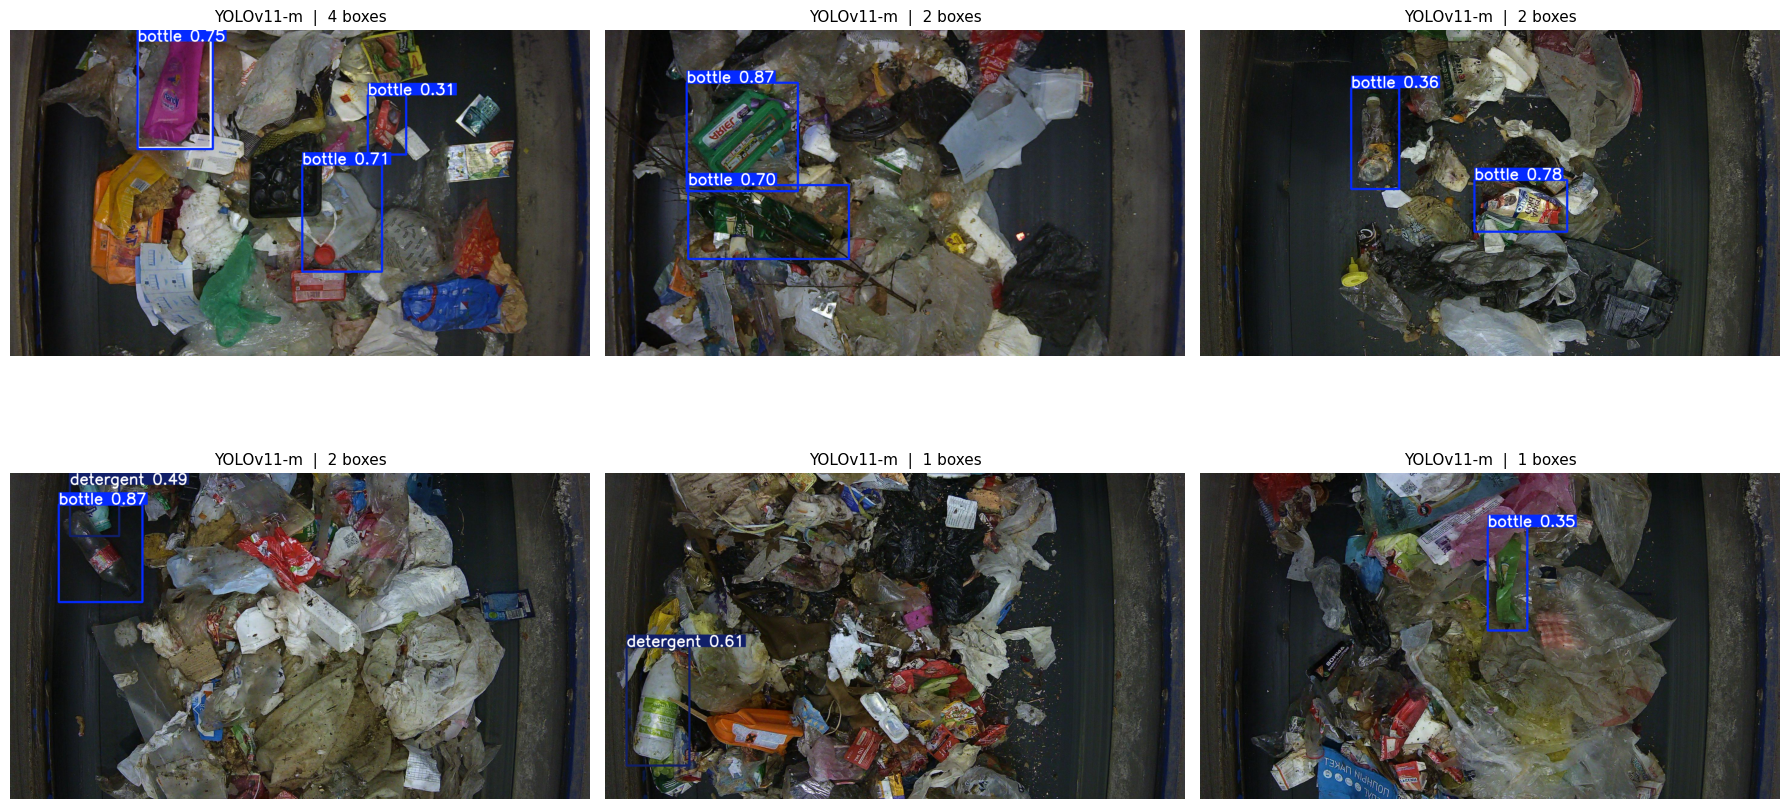


========== HEADLINE METRICS ==========
 Detector  Params (M)  Epochs  mAP@0.5  mAP@0.5:0.95  Precision  Recall
YOLOv11-m        20.1      50   0.5473        0.4321     0.7134  0.4821

========== PER-CLASS BREAKDOWN ==========
    Class  Precision  Recall  mAP@0.5  mAP@0.5:0.95
   bottle     0.7713  0.5866   0.7116        0.5297
 canister     1.0000  0.0000   0.0805        0.0621
     cans     0.4212  0.3256   0.3673        0.2716
cardboard     0.7713  0.7188   0.7969        0.6404
detergent     0.6030  0.7795   0.7801        0.6569

All outputs saved to: /content/drive/MyDrive/WaRP_Detection


In [ ]:
# qualitative grid + summary tables (loads from Drive)
import cv2, glob, os, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

# Load weights from the Drive copy (always survives runtime resets)
WEIGHTS = f'{DRIVE_DIR}/yolo11m_warp_super/weights/best.pt'
print(f"Loading: {WEIGHTS}")
model_yolo = YOLO(WEIGHTS)

# Re-run validation to populate metrics_yolo
metrics_yolo = model_yolo.val(
    data='/content/warp_super.yaml',
    split='test',
    plots=True,
    verbose=False
)

# Qualitative 2×3 grid (Fig. 14)
DST = Path('/content/WaRP-D-Super')
test_imgs = sorted(glob.glob(f'{DST}/test/images/*.jpg'))[:6]
if not test_imgs:
    test_imgs = sorted(glob.glob(f'{DST}/test/images/*.png'))[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, p in enumerate(test_imgs):
    r = model_yolo.predict(p, conf=0.30, verbose=False)[0]
    ax = axes[i // 3, i % 3]
    ax.imshow(cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB))
    ax.set_title(f'YOLOv11-m  |  {len(r.boxes)} boxes', fontsize=11)
    ax.axis('off')
plt.tight_layout()
plt.savefig(f'{DRIVE_DIR}/yolo11_qualitative.png', dpi=150, bbox_inches='tight')
plt.show()

# Headline + per-class summary tables (saved to Drive)
summary = pd.DataFrame({
    'Detector'      : ['YOLOv11-m'],
    'Params (M)'    : [20.1],
    'Epochs'        : [50],
    'mAP@0.5'       : [round(metrics_yolo.box.map50, 4)],
    'mAP@0.5:0.95'  : [round(metrics_yolo.box.map,   4)],
    'Precision'     : [round(metrics_yolo.box.mp,    4)],
    'Recall'        : [round(metrics_yolo.box.mr,    4)],
})

class_names = ['bottle', 'canister', 'cans', 'cardboard', 'detergent']
per_class = pd.DataFrame({
    'Class'        : class_names,
    'Precision'    : [round(p, 4) for p in metrics_yolo.box.p],
    'Recall'       : [round(r, 4) for r in metrics_yolo.box.r],
    'mAP@0.5'      : [round(a, 4) for a in metrics_yolo.box.ap50],
    'mAP@0.5:0.95' : [round(a, 4) for a in metrics_yolo.box.ap],
})

print("\n========== HEADLINE METRICS ==========")
print(summary.to_string(index=False))
print("\n========== PER-CLASS BREAKDOWN ==========")
print(per_class.to_string(index=False))

summary.to_csv(f'{DRIVE_DIR}/yolo11_results.csv', index=False)
per_class.to_csv(f'{DRIVE_DIR}/yolo11_per_class.csv', index=False)
print(f"\nAll outputs saved to: {DRIVE_DIR}")

## Cascade Implementation

### Import Libraries

In [1]:
!pip install ultralytics timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.8 MB/s eta 0:00:00


In [2]:
import cv2
import torch
import timm
import numpy as np

from ultralytics import YOLO
from torchvision import transforms
from PIL import Image

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
!ls /content/drive/MyDrive

ls: cannot access '/content/drive/MyDrive': No such file or directory


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Load Models Path from Drive

In [5]:
YOLO_PATH = "/content/drive/MyDrive/WaRP_Detection/yolo11m_warp_super/weights/best.pt"

VIT_PATH = "/content/drive/MyDrive/MODELS/ViT/vit_b_16.pth"

In [22]:
!ls "/content/drive/MyDrive/WaRP_Detection/yolo11m_warp_super/weights/best.pt"

/content/drive/MyDrive/WaRP_Detection/yolo11m_warp_super/weights/best.pt


In [6]:
!ls "/content/drive/MyDrive/MODELS/ViT"

vit_b_16_history.pkl  vit_b_16_metrics.pkl  vit_b_16_preds.npz	vit_b_16.pth


### Load Models

In [7]:
import torch
import torch.nn as nn

from torchvision.models import vit_b_16

# Create ViT
vit_model = vit_b_16(weights=None)

# SAME head used during training
vit_model.heads.head = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(
        vit_model.heads.head.in_features,
        28
    )
)

# Load checkpoint
checkpoint = torch.load(VIT_PATH)

vit_model.load_state_dict(checkpoint)

# GPU
vit_model.cuda().eval()

print("ViT loaded successfully!")

ViT loaded successfully!


### Preprocessing

In [8]:
def preprocess(image_bgr, size=224):

    image_rgb = cv2.cvtColor(
        image_bgr,
        cv2.COLOR_BGR2RGB
    )

    pil = Image.fromarray(image_rgb)

    transform = transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    return transform(pil)

### Mapping parent classes to leaf

In [9]:
super_to_leaf = {
    0: [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,25,26,27],
    1: [21],
    2: [22],
    3: [23,24],
    4: [18,19,20]
}

### Cascade classes

In [34]:
class WaRPCascade:
    def __init__(self, det_path, cls_model, super_to_leaf):
        self.det = YOLO(det_path)
        self.cls = cls_model.cuda().eval()
        self.super_to_leaf = super_to_leaf

    @torch.inference_mode()
    def predict(self, image_bgr, conf=0.05):
        # 1. Detect objects
        result = self.det.predict(image_bgr, conf=conf, verbose=False)[0]
        outputs = []

        for b in result.boxes:
            x1, y1, x2, y2 = b.xyxy[0].int().tolist()
            super_cls = int(b.cls)

            # 2. Crop and handle boundaries
            h, w = image_bgr.shape[:2]
            crop = image_bgr[max(0, y1-5):min(h, y2+5), max(0, x1-5):min(w, x2+5)]

            if crop.size == 0:
                continue

            # 3. Classify crop
            tensor = preprocess(crop).cuda().unsqueeze(0)
            logits = self.cls(tensor)[0]

            # 4. Apply hierarchical mask (force leaf to match super-class)
            mask = torch.full((28,), -1e9, device=logits.device)
            mask[self.super_to_leaf[super_cls]] = 0

            probs = (logits + mask).softmax(0)
            leaf_cls = int(probs.argmax())

            # Combine scores
            score = float(b.conf) * float(probs[leaf_cls])

            outputs.append({
                "bbox": (x1, y1, x2, y2),
                "super_class": super_cls,
                "leaf_class": leaf_cls,
                "score": score
            })
        return outputs

### cascading detector and classifier

In [35]:
cascade = WaRPCascade(
    det_path=YOLO_PATH,
    cls_model=vit_model,
    super_to_leaf=super_to_leaf
)

### Upload Image

In [45]:
from google.colab import files

uploaded = files.upload()

Saving Monitoring_photo_04-Mar_04-29-09_02.jpg to Monitoring_photo_04-Mar_04-29-09_02.jpg


In [46]:
import cv2

image = cv2.imread("Monitoring_photo_04-Mar_04-29-09_02.jpg")



In [47]:
print(image.shape)

(177, 264, 3)


### Results

In [48]:
results = cascade.predict(image)

print(results)

[{'bbox': (165, 55, 231, 127), 'super_class': 0, 'leaf_class': 0, 'score': 0.042340832392065986}]


In [49]:
result =cascade.det.predict(image,conf=0.05,verbose=True)[0]
print(result.boxes)


0: 448x640 1 bottle, 30.2ms
Speed: 2.5ms preprocess, 30.2ms inference, 1.8ms postprocess per image at shape (1, 3, 448, 640)
ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0.], device='cuda:0')
conf: tensor([0.0565], device='cuda:0')
data: tensor([[1.6546e+02, 5.5058e+01, 2.3135e+02, 1.2702e+02, 5.6536e-02, 0.0000e+00]], device='cuda:0')
id: None
is_track: False
orig_shape: (177, 264)
shape: torch.Size([1, 6])
xywh: tensor([[198.4017,  91.0406,  65.8881,  71.9657]], device='cuda:0')
xywhn: tensor([[0.7515, 0.5144, 0.2496, 0.4066]], device='cuda:0')
xyxy: tensor([[165.4576,  55.0578, 231.3457, 127.0235]], device='cuda:0')
xyxyn: tensor([[0.6267, 0.3111, 0.8763, 0.7176]], device='cuda:0')


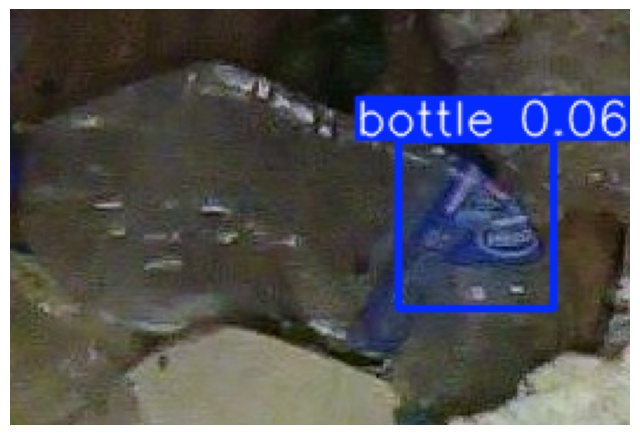

In [50]:
from matplotlib import pyplot as plt
import cv2

annotated = result.plot()

plt.figure(figsize=(8,8))

plt.imshow(cv2.cvtColor(
    annotated,
    cv2.COLOR_BGR2RGB
))

plt.axis("off")
plt.show()


In [51]:
print(cascade.det.names)

{0: 'bottle', 1: 'canister', 2: 'cans', 3: 'cardboard', 4: 'detergent'}


In [52]:
class_names = [
    'bottle-blue', 'bottle-green', 'bottle-dark',
    'bottle-milk', 'bottle-transp', 'bottle-multicolor',
    'bottle-yogurt', 'bottle-oil',
    'bottle-blue5l', 'bottle-blue5l-full',
    'bottle-blue-full', 'bottle-dark-full',
    'bottle-green-full', 'bottle-milk-full',
    'bottle-multicolorv-full',
    'bottle-transp-full',
    'bottle-yogurt-full',
    'bottle-oil-full',
    'detergent-color',
    'detergent-transparent',
    'detergent-box',
    'canister',
    'cans',
    'juice-cardboard',
    'milk-cardboard',
    'unknown-plastic',
    'glass-transp',
    'glass-dark'
]

for r in results:

    x1, y1, x2, y2 = r["bbox"]

    cls_name = class_names[r["leaf_class"]]

    score = r["score"]

    cv2.rectangle(
        image,
        (x1, y1),
        (x2, y2),
        (0,255,0),
        2
    )

    cv2.putText(
        image,
        f"{cls_name} ({score:.2f})",
        (x1, y1-10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0,255,0),
        2
    )

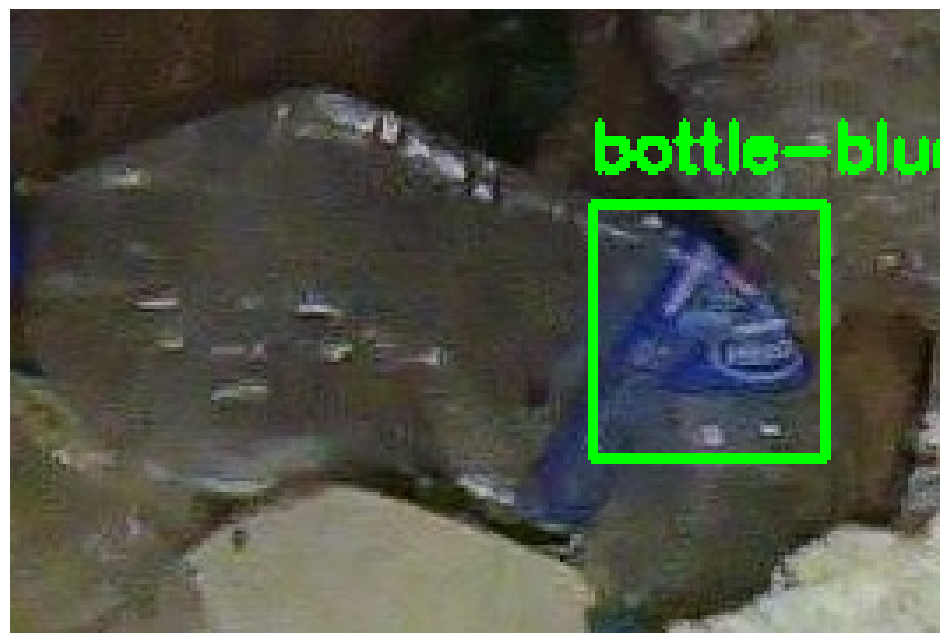

In [53]:
from matplotlib import pyplot as plt

plt.figure(figsize=(12,12))

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

plt.axis("off")

plt.show()

### Save Final Output Image

In [54]:
cv2.imwrite(
    "cascade_output.jpg",
    image
)

True

### Download Result

In [55]:
from google.colab import files

files.download("cascade_output.jpg")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>